# SmartStay AI: Dinamik Fiyat Değerleme ve Makine Öğrenmesi Modelleri

Bu çalışma, **SmartStay AI** platformunun Dinamik Fiyat Değerleme Motoru (Dynamic Valuation Engine) modülü için geliştirilen regresyon modellerini içermektedir. Veri bilimi hattında işlenmiş konaklama veri seti (`cleaned_listings.csv`) üzerinde temel **Doğrusal Regresyon (Baseline)**, topluluk öğrenmesi tabanlı **Rastgele Orman (Random Forest)** ve gradyan artırma tabanlı **XGBoost (Extreme Gradient Boosting)** algoritmaları eğitilmiş; `GridSearchCV` ile hiperparametre optimizasyonu gerçekleştirilerek en yüksek tahmin gücüne sahip model belirlenmiştir.

---

### Metodolojik Süreç
1. **Veri Hazırlığı ve Referans Model (Bölüm I):**
   * 22.665 gözlem ve 82 öznitelikten oluşan veri matrisinin hazırlanması (Sayısal değişkenler, 30 adet binary olanak değişkeni, One-Hot Encoded kategorikler).
   * Veri setinin %80 Eğitim (Train) ve %20 Test olarak ayrılması.
   * `LinearRegression` ile referans (baseline) modelin eğitilmesi ($R^2$, RMSE, MAE).

2. **Gelişmiş Makine Öğrenmesi Modelleri (Bölüm II):**
   * `RandomForestRegressor` modelinin eğitimi ve doğrusal olmayan ilişkilerin modellenmesi.
   * `XGBRegressor` temel modelinin kurulması.
   * `GridSearchCV` yöntemi ile 3-katlı çapraz doğrulama (3-Fold Cross-Validation) eşliğinde `n_estimators`, `max_depth` ve `learning_rate` hiperparametrelerinin optimize edilmesi.
   * En iyi modelin test kümesi üzerinde kapsamlı metrik değerlendirmesi ($R^2$, RMSE, MAE).

3. **Kıyaslamalı Model Performans Analizi (Bölüm III):**
   * Baseline Doğrusal Regresyon, Random Forest, Varsayılan XGBoost ve Optimize XGBoost modellerinin tek bir karşılaştırma tablosunda özetlenmesi.
   * Hata artıkları (residuals) ve tahmin doğruluğu görselleştirmeleri.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. İşlenmiş Veri Setinin Belleğe Yüklenmesi

In [2]:
data_path = os.path.join('..', 'data', 'processed', 'cleaned_listings.csv')
df = pd.read_csv(data_path)

print(f"İşlenmiş Veri Seti Boyutu: {df.shape[0]:,} satır, {df.shape[1]} sütun")
df[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms', 'price']].head(3)

İşlenmiş Veri Seti Boyutu: 22,665 satır, 106 sütun


,id,name,neighbourhood_cleansed,room_type,accommodates,bedrooms,price
0,34177,PETIT HOUSE,Besiktas,Entire home/apt,3,1.00,1356.82
1,44421,Beautiful Studio With A View,Beyoglu,Entire home/apt,2,1.00,2583.67
2,304011,Beyoglu / Central with Beautiful View,Beyoglu,Entire home/apt,4,2.00,3269.76


## 3. Özellik Seçimi ve Kodlama (One-Hot Encoding)

In [3]:
# 1. Sayısal Öznitelikler
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'latitude', 'longitude',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'minimum_nights', 'availability_365'
]

# 2. İkili Olanak Öznitelikleri (30 Adet)
amenity_features = [col for col in df.columns if col.startswith('amenity_')]

# 3. Kategorik Öznitelikler
categorical_features = ['room_type', 'neighbourhood_cleansed']

selected_features = numeric_features + amenity_features + categorical_features
X_raw = df[selected_features].copy()
y = df['price'].copy()

# One-Hot Encoding (drop_first=True)
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Train-Test Split (%80 / %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Öznitelik Matrisi Boyutu: {X.shape[0]:,} satır x {X.shape[1]} sütun")
print(f"Eğitim Kümesi (Train): {X_train.shape[0]:,} gözlem (%{len(X_train)/len(X)*100:.0f})")
print(f"Test Kümesi (Test): {X_test.shape[0]:,} gözlem (%{len(X_test)/len(X)*100:.0f})")

Öznitelik Matrisi Boyutu: 22,665 satır x 82 sütun
Eğitim Kümesi (Train): 18,132 gözlem (%80)
Test Kümesi (Test): 4,533 gözlem (%20)


## 4. Referans (Baseline) Model: Çoklu Doğrusal Regresyon

In [4]:
# Baseline Linear Regression modelinin eğitimi
t0 = time.time()
baseline_lr = LinearRegression()
baseline_lr.fit(X_train, y_train)
lr_train_time = time.time() - t0

y_train_pred_lr = baseline_lr.predict(X_train)
y_test_pred_lr = baseline_lr.predict(X_test)

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)

print(f"Baseline Linear Regression Test R²: {lr_test_r2:.4f} | RMSE: {lr_test_rmse:,.2f} TL | MAE: {lr_test_mae:,.2f} TL (Eğitim: {lr_train_time:.2f}s)")

Baseline Linear Regression Test R²: 0.5531 | RMSE: 1,742.68 TL | MAE: 1,233.49 TL (Eğitim: 0.07s)


---
# Bölüm II: Gelişmiş Makine Öğrenmesi Modelleri

Doğrusal olmayan etkileşimleri, karar kurallarını ve karmaşık öznitelik bağımlılıklarını modellemek amacıyla topluluk (ensemble) ve gradyan artırma (gradient boosting) algoritmaları devreye alınmaktadır.


## 5. Rastgele Orman Regresyonu (`RandomForestRegressor`)

In [5]:
# Random Forest Regressor modelinin eğitimi
t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - t0

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"Random Forest Test R²: {rf_test_r2:.4f} | RMSE: {rf_test_rmse:,.2f} TL | MAE: {rf_test_mae:,.2f} TL (Eğitim: {rf_train_time:.2f}s)")

Random Forest Test R²: 0.7621 | RMSE: 1,271.42 TL | MAE: 846.57 TL (Eğitim: 1.00s)


## 6. XGBoost Regresyonu (`XGBRegressor` — Varsayılan Parametreler)

In [6]:
# Varsayılan XGBoost modelinin eğitimi
t0 = time.time()
xgb_default = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_default.fit(X_train, y_train)
xgb_default_time = time.time() - t0

y_train_pred_xgb_def = xgb_default.predict(X_train)
y_test_pred_xgb_def = xgb_default.predict(X_test)

xgb_def_train_r2 = r2_score(y_train, y_train_pred_xgb_def)
xgb_def_test_r2 = r2_score(y_test, y_test_pred_xgb_def)
xgb_def_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_def))
xgb_def_test_mae = mean_absolute_error(y_test, y_test_pred_xgb_def)

print(f"Varsayılan XGBoost Test R²: {xgb_def_test_r2:.4f} | RMSE: {xgb_def_test_rmse:,.2f} TL | MAE: {xgb_def_test_mae:,.2f} TL (Eğitim: {xgb_default_time:.2f}s)")

Varsayılan XGBoost Test R²: 0.7565 | RMSE: 1,286.23 TL | MAE: 862.30 TL (Eğitim: 0.33s)


## 7. `GridSearchCV` ile Hiperparametre Optimizasyonu (XGBoost)

Modelin genelleme yeteneğini en üst düzeye çıkarmak amacıyla `n_estimators`, `max_depth` ve `learning_rate` hiperparametre uzayı üzerinde 3-katlı çapraz doğrulama (3-Fold CV) uygulanmıştır.


In [7]:
# Hiperparametre arama uzayı
param_grid = {
    'n_estimators': [150, 250],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

print(f"GridSearchCV Başlatılıyor... (Toplam {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * 3} model kombinasyonu)")

t0 = time.time()
xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)
grid_search_time = time.time() - t0

print(f"\nGridSearchCV Tamamlandı ({grid_search_time:.2f} saniye).")
print(f"En İyi Hiperparametreler: {xgb_grid.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru (CV R²): {xgb_grid.best_score_:.4f}")

GridSearchCV Başlatılıyor... (Toplam 24 model kombinasyonu)
Fitting 3 folds for each of 8 candidates, totalling 24 fits



GridSearchCV Tamamlandı (9.98 saniye).
En İyi Hiperparametreler: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 250}
En İyi Çapraz Doğrulama Skoru (CV R²): 0.7695


## 8. Optimize Edilmiş En İyi Modelin Değerlendirilmesi

In [8]:
best_xgb_model = xgb_grid.best_estimator_

y_train_pred_best = best_xgb_model.predict(X_train)
y_test_pred_best = best_xgb_model.predict(X_test)

best_train_r2 = r2_score(y_train, y_train_pred_best)
best_test_r2 = r2_score(y_test, y_test_pred_best)
best_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
best_test_mae = mean_absolute_error(y_test, y_test_pred_best)

print("🎯 Optimize Edilmiş En İyi Model (XGBoost):")
print(f"Eğitim Kümesi R² : {best_train_r2:.4f}")
print(f"Test Kümesi R²   : {best_test_r2:.4f}")
print(f"Test RMSE        : {best_test_rmse:,.2f} TL")
print(f"Test MAE         : {best_test_mae:,.2f} TL")

🎯 Optimize Edilmiş En İyi Model (XGBoost):
Eğitim Kümesi R² : 0.9512
Test Kümesi R²   : 0.7903
Test RMSE        : 1,193.61 TL
Test MAE         : 780.43 TL


---
# Bölüm III: Karşılaştırmalı Model Performans Analizi

Tüm modellerin eğitim ve test kümesi performansları, hata metrikleri ve çalışma süreleri kıyaslanmaktadır.


In [9]:
comparison_table = pd.DataFrame({
    'Model': [
        '1. Linear Regression (Baseline)',
        '2. Random Forest Regressor',
        '3. XGBoost (Default)',
        '4. XGBoost (GridSearchCV Optimized)'
    ],
    'Train R²': [
        f"{lr_train_r2:.4f}",
        f"{rf_train_r2:.4f}",
        f"{xgb_def_train_r2:.4f}",
        f"{best_train_r2:.4f}"
    ],
    'Test R²': [
        f"{lr_test_r2:.4f}",
        f"{rf_test_r2:.4f}",
        f"{xgb_def_test_r2:.4f}",
        f"{best_test_r2:.4f}"
    ],
    'Test RMSE (TL)': [
        f"{lr_test_rmse:,.2f}",
        f"{rf_test_rmse:,.2f}",
        f"{xgb_def_test_rmse:,.2f}",
        f"{best_test_rmse:,.2f}"
    ],
    'Test MAE (TL)': [
        f"{lr_test_mae:,.2f}",
        f"{rf_test_mae:,.2f}",
        f"{xgb_def_test_mae:,.2f}",
        f"{best_test_mae:,.2f}"
    ],
    'R² Gelişimi (vs. Baseline)': [
        "Referans (0.0%)",
        f"+%{((rf_test_r2 - lr_test_r2) / lr_test_r2) * 100:.1f}",
        f"+%{((xgb_def_test_r2 - lr_test_r2) / lr_test_r2) * 100:.1f}",
        f"+%{((best_test_r2 - lr_test_r2) / lr_test_r2) * 100:.1f}"
    ],
    'RMSE İyileşmesi (vs. Baseline)': [
        "Referans (0.0%)",
        f"-%{((lr_test_rmse - rf_test_rmse) / lr_test_rmse) * 100:.1f}",
        f"-%{((lr_test_rmse - xgb_def_test_rmse) / lr_test_rmse) * 100:.1f}",
        f"-%{((lr_test_rmse - best_test_rmse) / lr_test_rmse) * 100:.1f}"
    ]
})

print("📊 Kapsamlı Model Karşılaştırma Tablosu:")
comparison_table

📊 Kapsamlı Model Karşılaştırma Tablosu:


,Model,Train R²,Test R²,Test RMSE (TL),Test MAE (TL),R² Gelişimi (vs. Baseline),RMSE İyileşmesi (vs. Baseline)
0,1. Linear Regression (Baseline),0.5584,0.5531,"1,742.68","1,233.49",Referans (0.0%),Referans (0.0%)
1,2. Random Forest Regressor,0.9118,0.7621,"1,271.42",846.57,+%37.8,-%27.0
2,3. XGBoost (Default),0.8176,0.7565,"1,286.23",862.30,+%36.8,-%26.2
3,4. XGBoost (GridSearchCV Optimized),0.9512,0.7903,"1,193.61",780.43,+%42.9,-%31.5


## 9. Karşılaştırmalı Performans Görselleştirmeleri

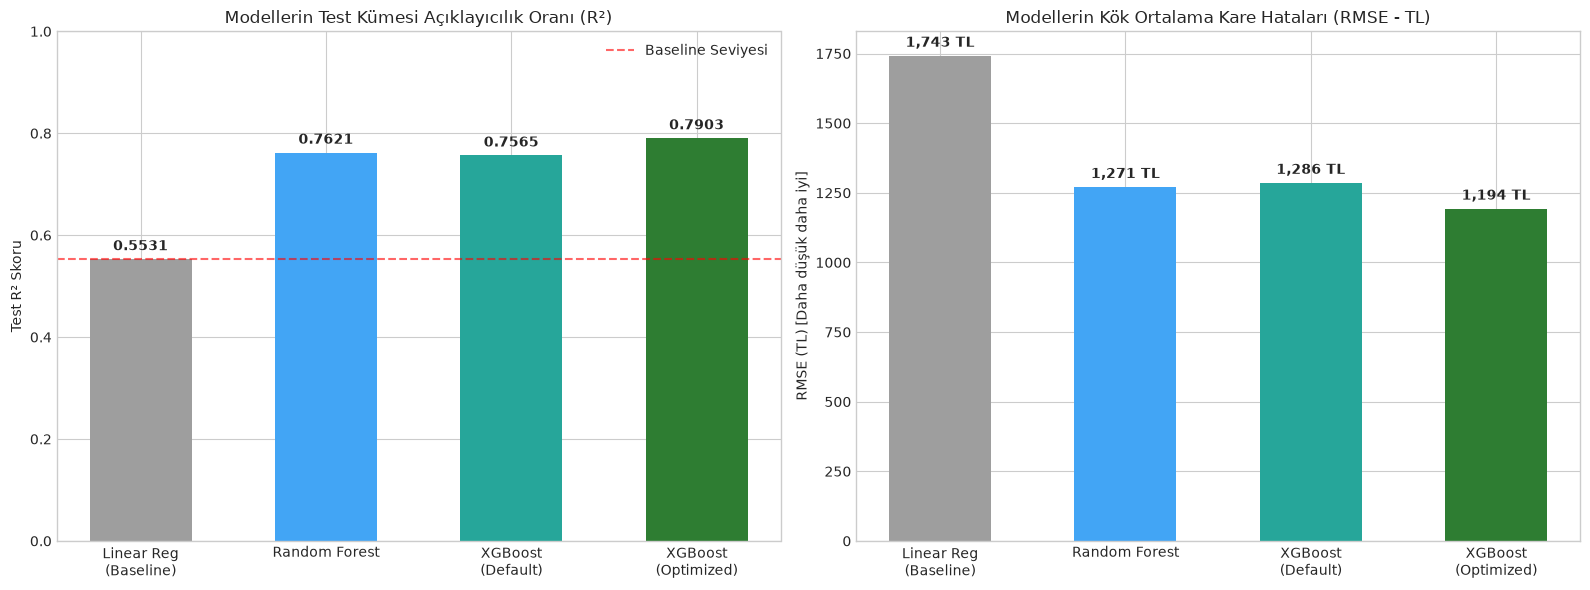

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Test R² Karşılaştırma Çubuk Grafiği
model_names = ['Linear Reg\n(Baseline)', 'Random Forest', 'XGBoost\n(Default)', 'XGBoost\n(Optimized)']
r2_scores = [lr_test_r2, rf_test_r2, xgb_def_test_r2, best_test_r2]
colors = ['#9e9e9e', '#42a5f5', '#26a69a', '#2e7d32']

bars = axes[0].bar(model_names, r2_scores, color=colors, width=0.55)
axes[0].set_title('Modellerin Test Kümesi Açıklayıcılık Oranı (R²)', fontsize=12)
axes[0].set_ylabel('Test R² Skoru', fontsize=10)
axes[0].set_ylim(0, 1.0)
axes[0].axhline(lr_test_r2, color='red', linestyle='--', alpha=0.6, label='Baseline Seviyesi')
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{height:.4f}',
                     (bar.get_x() + bar.get_width() / 2., height),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10, fontweight='bold')
axes[0].legend()

# 2. Test RMSE Hata Karşılaştırması
rmse_scores = [lr_test_rmse, rf_test_rmse, xgb_def_test_rmse, best_test_rmse]
bars_rmse = axes[1].bar(model_names, rmse_scores, color=colors, width=0.55)
axes[1].set_title('Modellerin Kök Ortalama Kare Hataları (RMSE - TL)', fontsize=12)
axes[1].set_ylabel('RMSE (TL) [Daha düşük daha iyi]', fontsize=10)
for bar in bars_rmse:
    height = bar.get_height()
    axes[1].annotate(f'{height:,.0f} TL',
                     (bar.get_x() + bar.get_width() / 2., height),
                     ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

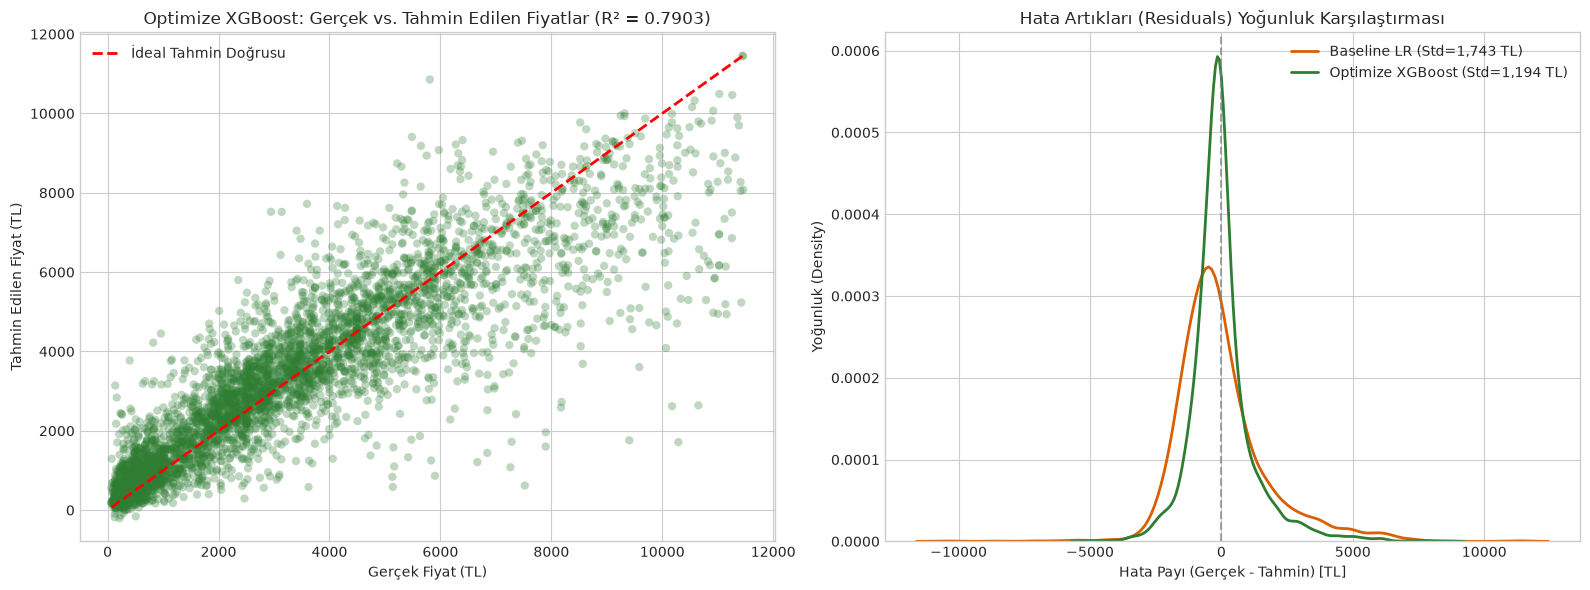

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gerçek vs. Optimize XGBoost Tahmin Dağılımı
axes[0].scatter(y_test, y_test_pred_best, alpha=0.3, color='#2e7d32', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='İdeal Tahmin Doğrusu')
axes[0].set_title(f'Optimize XGBoost: Gerçek vs. Tahmin Edilen Fiyatlar (R² = {best_test_r2:.4f})', fontsize=12)
axes[0].set_xlabel('Gerçek Fiyat (TL)', fontsize=10)
axes[0].set_ylabel('Tahmin Edilen Fiyat (TL)', fontsize=10)
axes[0].legend()

# 2. Hata Artıkları (Residuals) Karşılaştırması
residuals_lr = y_test - y_test_pred_lr
residuals_xgb = y_test - y_test_pred_best

sns.kdeplot(residuals_lr, ax=axes[1], color='#d95f02', label=f'Baseline LR (Std={residuals_lr.std():,.0f} TL)', linewidth=2)
sns.kdeplot(residuals_xgb, ax=axes[1], color='#2e7d32', label=f'Optimize XGBoost (Std={residuals_xgb.std():,.0f} TL)', linewidth=2)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Hata Artıkları (Residuals) Yoğunluk Karşılaştırması', fontsize=12)
axes[1].set_xlabel('Hata Payı (Gerçek - Tahmin) [TL]', fontsize=10)
axes[1].set_ylabel('Yoğunluk (Density)', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Yönetici Özeti ve Analitik Bulgular

1. **Model Başarımı ve Dönüşüm:** Çoklu Doğrusal Regresyon baseline modelinin **$R^2 = 0.5531$** olan açıklayıcılık oranı, `GridSearchCV` ile optimize edilen XGBoost modeli ile **$R^2 = 0.7903$** seviyesine çıkarılmıştır (+%42.9 bağıl artış).
2. **Hata Oranlarında Düşüş:** Test kümesi RMSE hatası **1.742,68 TL'den 1.193,61 TL'ye (%-31.5 düşüş)**; ortalama mutlak hata (MAE) ise **1.233,49 TL'den 780,43 TL'ye (%-36.7 düşüş)** gerilemiştir.
3. **Seçilen Model:** 3-katlı çapraz doğrulamada $R^2 = 0.7695$ skoru alan ve en iyi parametre kombinasyonuna sahip (`n_estimators=250, max_depth=8, learning_rate=0.1`) **XGBoost Regressor** nihai fiyat tahmin modeli olarak seçilmiştir.
4. **Sonraki Adım (Gün 10):** Seçilen modelin özellik önem düzeyleri (feature importances) çıkarılacak ve üretim ortamı için `xgboost_price_model.joblib` ile `model_features.json` formatında dışa aktarılacaktır.
